<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/NightTime_Light_Pollution_Bar_Graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

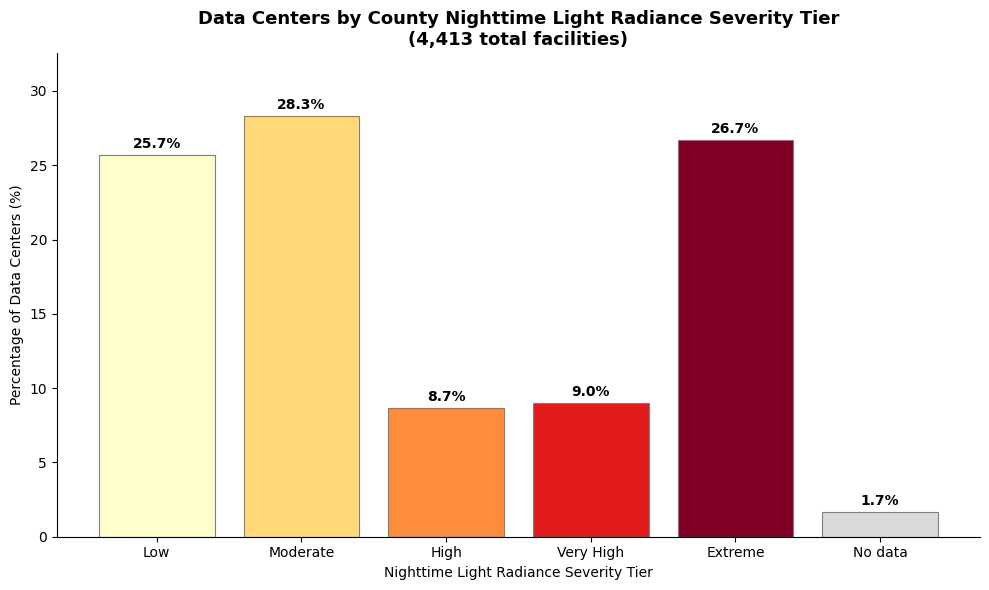

In [2]:
# Run once
# !pip install numpy pandas matplotlib openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Load & clean county-level nighttime light data ----
file = "/content/ALAN_VIIRS_CONUS_2012_to_2020_census_tract_level.xlsx"

alan_data = pd.read_excel(
    file,
    sheet_name="2020_boundary_ALAN_2012_to_2020"
)

# Keep only 2020 data
alan_2020 = alan_data[alan_data["year"] == 2020].copy()

# Make sure important columns are numeric
alan_2020["rad_mean"] = pd.to_numeric(alan_2020["rad_mean"], errors="coerce")
alan_2020["nraster"] = pd.to_numeric(alan_2020["nraster"], errors="coerce")

# Remove missing values
alan_2020 = alan_2020[
    alan_2020["rad_mean"].notna() &
    alan_2020["nraster"].notna()
].copy()

# Make county FIPS match shapefile GEOID
alan_2020["county_ID"] = (
    alan_2020["county_ID"]
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

# Calculate weighted radiance
alan_2020["weighted_rad"] = alan_2020["rad_mean"] * alan_2020["nraster"]

# Group census tract data into county-level data
county_light = alan_2020.groupby("county_ID").agg({
    "weighted_rad": "sum",
    "nraster": "sum"
}).reset_index()

# Calculate true average radiance by county
county_light["true_rad_mean"] = county_light["weighted_rad"] / county_light["nraster"]

# ---- Load data center / facility locations ----
facilities_file = "/content/facilities_final_complete.xlsx"

facilities = pd.read_excel(
    facilities_file,
    sheet_name="facilities_final_complete"
)

# Clean fips the same way as the county data so they can be matched
facilities["fips"] = facilities["fips"].astype(int).astype(str).str.zfill(5)

total_facility_count = len(facilities)

# ---- Build the same 5-tier nighttime light scale used on the map ----
# (2nd-98th percentile range split into 5 equal-width bins)
rad_values = county_light["true_rad_mean"].dropna()
vmin = rad_values.quantile(0.02)
vmax = rad_values.quantile(0.98)
bins = np.linspace(vmin, vmax, 6)

county_light["rad_bin"] = pd.cut(
    county_light["true_rad_mean"],
    bins=bins,
    labels=False,
    include_lowest=True
)

# Clamp out-of-range values into the first/last tier
county_light.loc[county_light["true_rad_mean"] < vmin, "rad_bin"] = 0
county_light.loc[county_light["true_rad_mean"] > vmax, "rad_bin"] = 4

# ---- Match each facility to its county's nighttime light tier ----
facility_tiers = facilities.merge(
    county_light[["county_ID", "rad_bin"]],
    left_on="fips",
    right_on="county_ID",
    how="left"
)

# Nighttime light severity tier names & colors, low -> high (same as map legend)
tier_names = ["Low", "Moderate", "High", "Very High", "Extreme"]
tier_colors = ["#FFFFCC", "#FED976", "#FD8D3C", "#E31A1C", "#800026"]
missing_color = "#D9D9D9"

# Count data centers in each tier
counts = [(facility_tiers["rad_bin"] == i).sum() for i in range(5)]
no_data_count = facility_tiers["rad_bin"].isna().sum()

labels = tier_names + ["No data"]
values = counts + [no_data_count]
colors = tier_colors + [missing_color]

# Convert counts to a percentage of all facilities
percentages = [v / total_facility_count * 100 for v in values]

# ---- Plot ----
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    labels,
    percentages,
    color=colors,
    edgecolor="#7f7f7f",
    linewidth=0.8
)

# Percentage label above each bar
for bar, pct in zip(bars, percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(percentages) * 0.01,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    f"Data Centers by County Nighttime Light Radiance Severity Tier\n({total_facility_count:,} total facilities)",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Nighttime Light Radiance Severity Tier")
ax.set_ylabel("Percentage of Data Centers (%)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, max(percentages) * 1.15)

plt.tight_layout()
plt.show()